# Looking at the historical US market returns

## Imports

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as pyplot
import datetime as dt

## Data

### Shiller's historical S&P 500 data

Importing the formatted data.

In [2]:
csv_path = '../../data/shiller/shiller_sp500_pandas_formatted.csv'
df = pd.read_csv(csv_path, parse_dates=['Date'])

## Dividend re-invested Compound Annual Growth Rate (CAGR)

### Reinvesting dividends

Suppose we have $s$ shares of an S&P 500 index fund, priced at $p$ dollars per share.  If the fund issues a dividend of $d$ dollars per share, we arrive at a total dividend payout of $D = sd$ dollars.  We can reinvest this payout back into the fund to purchase $\Delta s = D/p = sd/p$ new shares, resulting in $s_d$ total shares, where  
$s_d = s + \Delta s = s\left( 1 + d/p \right)$.

We didn't rely on any history of $s$ for this calculation, so the case where the initial shares $s$ already included a previous dividend payout follows automatically.  Indexing the first payout with `1` and the latter payout with `2`, we would find that the share count has evolved from a base value $s$ according to  
$s_{d,2} = s_{d,1}\left( 1 + d_2/p_2 \right) = s\left( 1 + d_1 / p_1 \right)\left( 1 + d_2/p_2 \right)$.  

More generally, the current number of shares from reinvesting dividends can be determined from the initial number of shares $s_0$ combined with the historical dividend payout per share $d$ and the price per share $p$ at the time of reinvestment.  
$s = s_0\prod_i\left( 1 + d_i/p_i \right)$

### Dividends in Shiller's data

Per [Shiller's website description](https://shillerdata.com/), the monthly dividend data are really linear interpolations of longer timeframes.  E.g., the dividends since 1926 are interpolated from S&P quarterly results on dividend payouts.  What's _not stated_ directly on the data website is that the `Dividend` column apparently represents the trailing 12-month dividend total payout for the S&P 500.  The full explanation can be found [on Shiller's Yale page](http://www.econ.yale.edu/~shiller/data/chapt26.html) discussing chapter 26 of his _Market Volatility_ text.  I only really stumbled onto this definition after first seeing it on [multpl](https://www.multpl.com/s-p-500-dividend) and doing some Google hunting for Shiller's specific description.

Currently, I'm simply dividing the `Dividend` column value by 12 to approximate a monthly dividend payout used to calculate monthly reinvestment.  This has the effect of smoothing out the dividend reinvestments, in a kind of dollar-cost-averaging of dividend payouts.  On some level, this might be reasonable for an analysis that only tracks the S&P 500 on a monthly basis, but it's certain to introduce some (hopefully sub-leading) error.

### Compound Annual Growth Rate (CAGR) with dividends reinvested

To calculate the Compound Annual Growth Rate (CAGR) over a period of time using the Shiller data, we can apply the dividend reinvestment formulas with the additional approximation that the dividend payout per share is  
$d_i = D_{i, 12}/12$,  
where $D_{i,12}$ is the trailing 12-month total of dividends.  If the price per share of the S&P 500 index fund is $p_0$ at some initial time, then    
$(\text{initial value}) = p_0 s_0$.  
If the price per share is $p_f$ at some later time, then  
$(\text{final value}) = p_f s_f = p_f s_0 \prod_i\left( 1 + d_i/p_i \right) =
p_f s_0 \prod_i \left( 1 + D_i/12 p_i \right)$.  
The total growth ratio $G$ is given by the ratio  
$G := \frac{\text{(final value)}}{\text{(initial value)}}
= \frac{p_f}{p_0}\prod_i \left( 1 + D_i/12 p_i \right)$.  
The growth ratio can be related to an annually-compounded growth rate $r$,  
$G = \left( 1 + r \right)^{t_f - t_0}$,  
where $t_f - t_0$ is the period between initial and final times, in _years_.  Here, I'm avoiding the issue of fractional differences in years and simply allowing for fractional annual compounding, with the assumption that I will typically consider the CAGR over many years. The annually-compounded growth rate $r$ between periods of time in the Shiller data, with dividends reinvested, can be calculated via  
$r = G^{1/(t_f - t_0)} - 1
= \left[\frac{p_f}{p_0}\prod_i \left( 1 + D_i/12 p_i \right) \right]^{1/(t_f-t_0)} - 1$  

#### Pre-compute cumulative dividend reinvestment growth and dividend returns

Calculating the cumulative sum of dividend payouts in the case of not reinvesting dividends or the cumulative product of reinvested share growth is a costly calculation when done on-the-fly.  These calues can be pre-computed given the existing data in order to make the CAGR calculation $\mathcal O(1)$ between any investement period.

Given an arbitrary starting date in the historical S&P 500 data, we can initialize a reference share count $s_0$, which--without loss of generality--can be set to 1.  That said, I'll include $s_0$ for reference.  At each subsequent (in time) data point, we should use the previous entry to calculate the current share count,  
$s_j = s_{j-1}\left(  1 + D_j/12 p_j\right) = s_0\prod_{i\le j}\left( 1 + D_i/12 p_i \right)$,  
where $j$ is the index of the current data point, and the current cumulative dividend payout,  
$d^\Sigma_j = d^\Sigma_{j-1} + \left( D_j/12 p_j \right) = \sum_{i\le j}\left( D_i/12 p_i \right)$,  
where we also bootstrap the initial dividend payout as starting from 0.  These cumulative 
calculations involve the same number in overall operations (i.e., they're still linear in the total number of data points), but the cumulative operations may require some care to not incur a performance hit on large datasets.

Given the price $p_j$, cumulative dividend payout $d^\Sigma_j$ since the initial, and the current share count relative to the initial $s_j$ , we can calculate the CAGR between any two points in time, or indices $i$ and $f$, with and without dividend reinvestment in a straightforward manner.  Without dividend reinvestment, the ratio used in the CAGR calculation simply need to include the sum of dividends paid out during the investment period.  To make life easy, I'm currently ignoring any interest earned on these dividends, even though one would likely store cash reserves in some sort of interest-bearing account in reality.  The CAGR without dividend reinvestment, $r_{\text{no div}}$, is then   
$r_{\text{no div}} = \left[ \frac{p_f + (d^\Sigma_f - d^\Sigma_i)}{p_i} \right]^{1/(t_f-t_i)}$.  
I.e., the share count is irrelevant and we need only account for the cash value of dividends in addition to the price growth of the stock holdings.  With dividends, the CAGR $r$ involves the ratio of shares in addition to the price growth,  
$r = \left[ \frac{p_f s_f}{p_i s_i} \right]^{1/(t_f - t_i)}$.  

In [3]:
def precompute_dividend_values():
    """
    This function adds columns with cumulative dividend values to facilitate fast CAGR calculations.
    """

    # The "Dividend" column is the total dividend return of the S&P over the last 12 months.
    # This calculation approximates the current month's dividends by 1/12th of this rolling average.
    df["Cumulative Dividend"] = (df["Dividend"] / 12).cumsum()
    df["Cumulative Shares"] = (1 + df["Dividend"] / df["S&P"] / 12).cumprod()

# This function is idempotent, so go ahead and call it any time its definition is re-evaluated
precompute_dividend_values()

In [25]:
def cagr(initial: pd.Series, period: dt.timedelta, reinvest_dividends: bool=True, real: bool=False) -> float:
    """
    Calculates the Compound Annual Growth Rate (CAGR) between the final and initial periods,
    inclusive, where dividends are reinvested by default.
    - initial: The starting row of the CAGR calculation.
    - period: The datetime.timedelta over which to perform the CAGR calculation.
    - reinvest_dividends: [default True] A boolean flag to determine whether dividends are reinvested over the period.  If false, dividends are still tracked and accumulated, but they do not earn interest over the period of consideration.
    - real: [default False] A boolean flag to determine whether or not the CAGR is calculated using real (CPI adjusted) or nominal values of the S&P 500.
    """

    end = initial['Date'] + period
    final = df[df['Date'] <= end].iloc[-1]

    growth_ratio = calculate_growth_ratio(initial, final, reinvest_dividends, real)

    period = (final['Date'] - initial['Date']).days / 365.25  # CAUTION: wrong around 1900

    # Yearly compounding, ignoring issues with fractional year contributions
    return math.pow(growth_ratio, 1 / period) - 1

def calculate_growth_ratio(initial_row: pd.Series, final_row: pd.Series, reinvest_dividends: bool, real: bool) -> float:
    """
    Calculates the ratio of the final value to the initial value of the S&P for the input dataframe, including dividends.  Even if dividends are not reinvested, they are summed up and combined with the final portfolio value of the S&P.
    """

    initial = initial_row["S&P"]
    final = final_row["S&P"]

    # Adjust nominal values using the CPI
    if real:
        initial = initial / initial_row['CPI']
        final = final / final_row['CPI']

    if reinvest_dividends:
        # We include the share counts in each to measure share growth from reinvested dividends.
        initial = initial * initial_row["Cumulative Shares"]
        final = final * final_row["Cumulative Shares"]
    else:
        # Add the dividends paid out between the two intervals to the final value
        final = final + (final_row["Cumulative Dividend"] - initial_row["Cumulative Dividend"])
   
    return final / initial

#### Comparisons to online resources

The CAGR formulas here  are compared to two online resources (listed below) as a sanity check.  The calculations essentially agree with dqydj's values for reinvested dividends and are within a few percent of moneychimp's values.  The calculated CAGR is nearly 10% off (i.e., my calculated CAGR is about 1.1 times the CAGR of these other resources) in the case of uninvested dividends.  I suspect they're not tracking the dividends at all in these cases, but I could be missing something.

- [Don't Quit Your Day Job (dqydj)](https://dqydj.com/sp-500-return-calculator/)
- [moneychimp](http://www.moneychimp.com/features/market_cagr.htm)  [Note: the range Jan 1st 2014 to Dec 31st 2024 is likely different than the January 2014 -> January 2025 ranges used here and on dqydj.]

In [28]:
initial_date = dt.datetime(2014, 1, 1)
initial_row = df[df['Date'] <= initial_date].iloc[-1]
final_date = dt.datetime(2025, 1, 1)
period = final_date - initial_date
print("January 2014 to January 2025 comparisons\n\n")

with_dividends = cagr(initial_row, period)
moneychimp_dividend = 0.1319
dqydj_dividend = 0.13403
print("Calculated nominal CAGR with dividends:", with_dividends)
print("Relative to moneychimp:", with_dividends / moneychimp_dividend)
print("Relative to dqydj:", with_dividends / dqydj_dividend)

print("\n\n")

without_dividends = cagr(initial_row, period, reinvest_dividends=False)
moneychimp_without = 0.1111
dqydj_without = 0.11407
print("Calculated nominal CAGR without dividends:", without_dividends)
print("Relative to moneychimp:", without_dividends / moneychimp_without)
print("Relative to dqydj:", without_dividends / dqydj_without)

print("\n\n")

with_dividends_real = cagr(initial_row, period, real=True)
moneychimp_dividend_real = 0.1011
dqydj_dividend_real = 0.10291
print("Calculated real CAGR with dividends:", with_dividends_real)
print("Relative to moneychimp:", with_dividends_real / moneychimp_dividend_real)
print("Relative to dqydj:", with_dividends_real / dqydj_dividend_real)

print("\n\n")

without_dividends_real = cagr(initial_row, period, reinvest_dividends=False, real=True)
moneychimp_without_real = 0.0809
dqydj_without_real = 0.08350
print("Calculated real CAGR without dividends:", without_dividends_real)
print("Relative to moneychimp:", without_dividends_real / moneychimp_without_real)
print("Relative to dqydj:", without_dividends_real / dqydj_without_real)

January 2014 to January 2025 comparisons


Calculated nominal CAGR with dividends: 0.1340178429339436
Relative to moneychimp: 1.0160564286121576
Relative to dqydj: 0.9999092959333252



Calculated nominal CAGR without dividends: 0.12386741300488202
Relative to moneychimp: 1.1149182088648246
Relative to dqydj: 1.0858894801865697



Calculated real CAGR with dividends: 0.10290274544194467
Relative to moneychimp: 1.017831310009344
Relative to dqydj: 0.9999295058006478



Calculated real CAGR without dividends: 0.4895119889679329
Relative to moneychimp: 6.050828046575191
Relative to dqydj: 5.862419029556082


## Historical long term CAGR in Shiller's data

For now, I'm calculating and considering the CAGR in simple dollar terms without adjusting for inflation.  With the heuristic of ~3% CPI, the real CAGR is likely reduced by a similar amount.

### CAGR calculations over various periods

In [29]:
period_years = [5, 10, 15, 20, 25, 30, 40, 50, 60, 70, 80, 90, 100]

# entries: {'period': int, 'dates': pd.Series, 'cagr': pd.Series, 'cagr_no_div': pd.Series}
cagr_results = []

for years in period_years:
    result = {}
    result['period'] = years

    period = dt.timedelta(days = 365.25 * years)  # Poor man's leap years
    end = df['Date'].iloc[-1] - period  # Remove dates outside the analysis range
    rows = df[df['Date'] < end]
    result['dates'] = rows['Date']

    result['cagr'] = rows.apply(lambda row: cagr(row, period), axis=1)
    result['cagr_no_div'] = rows.apply(
        lambda row: cagr(row, period, reinvest_dividends=False),
        axis=1
    )
    result['cagr_real'] = rows.apply(lambda row: cagr(row, period, real=True), axis=1)

    cagr_results.append(result)

### Analysis of historical CAGR over 30 year time periods

First, let's isolate historical CAGR over 30 year investment periods.

#### Isolate 30 year CAGR results

In [30]:
for result in cagr_results:
    if result['period'] == 30:
        cagr_30_result = result

#### Plotted 30 year results

Since around the 1920s, it looks like you could rely on stable 10%+ CAGR for an investment in the S&P500, so long as dividends were reinvested.  Curiously, it seems like dividend reinvestment has not had nearly as much of an impact since around the 1980s.

The color legend might be tough to see, but the data points are obvious from how scattered they are.  Horizontal lines have been added as a guide to the eye, tracking some round CAGR values that I consider relevant plateaus in the data.  Most notable is the CAGR with dividends reinvested near the 10% CAGR line from 1920-1930, 1945-1965, and 1980-1996.  Of the gaps in those time periods, only the onset of the great depression around 1930-1935 experienced noticably reduced returns from 10% CAGR; all other periods (e.g., 1935-1945) experienced significantly increased CAGR.

Another notable plateua is the prior period, from the 1870s-1920.  I'm not sure how reliable the data is over this interval, but the CAGR for reinvested dividends seems to fluctuate around 7%.  

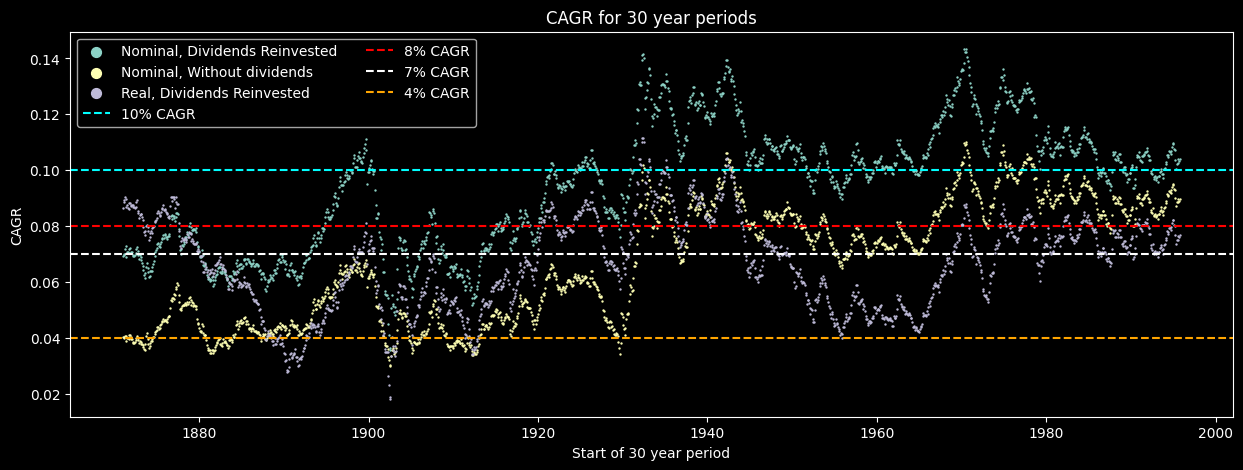

In [33]:
# Set (global) plot dimensions
pyplot.rcParams["figure.figsize"] = (15,5)
pyplot.style.use('dark_background')

# Pick out the relevant values for 30 year periods
dates = cagr_30_result['dates']
cagr = cagr_30_result['cagr']
cagr_no_div = cagr_30_result['cagr_no_div']
cagr_real = cagr_30_result['cagr_real']

# Data
pyplot.scatter(x=dates.to_list(), y=cagr.to_list(), s=0.5, label='Nominal, Dividends Reinvested')   
pyplot.scatter(x=dates.to_list(), y=cagr_no_div.to_list(), s=0.5, label='Nominal, Without dividends')
pyplot.scatter(x=dates.to_list(), y=cagr_real.to_list(), s=0.5, label='Real, Dividends Reinvested')

# Line guides
pyplot.axhline(y=0.10, color='cyan', linestyle='dashed', label='10% CAGR')
pyplot.axhline(y=0.08, color='red', linestyle='dashed', label='8% CAGR')
pyplot.axhline(y=0.07, linestyle='dashed', label='7% CAGR')
pyplot.axhline(y=0.04, color='orange', linestyle='dashed', label='4% CAGR')

# Labels and legends
pyplot.legend(markerscale=10, ncol=2)
pyplot.xlabel('Start of 30 year period')
pyplot.ylabel('CAGR')
pyplot.title('CAGR for 30 year periods')
pyplot.show()

### Analysis of historial CAGR over a wider range of periods

Plotting the historical CAGR over various investment periods reveals more consistent structure than I'd expect. While there's a lot of noise and visible offsets, the crazy plot with all values in one clearly shows two strong trends with dividends reinvested and without.  I.e., they cluster rather visibly around a similar CAGR despite the differing investment periods.

#### Investment periods of 30 years or more

The trend of ~10% nominal returns since the mid 1930s seems somewhat stable when looking at longer investment periods.  That said, the 30 year timeframe seems particularly rosy, as there are dips visible in the subsequent plots for 40 and 50 year invesment periods that aren't as pronounced when using 30 year snapshots.  Interestingly, the largest CAGR spikes are seen in the 30 year periods, but the since the mid 1930s, but the largest dips are actually seen in the 50 year (around 1960) and 40 year (around 1970) time periods.  Curiously, then, the 30 year period may be in a sweet spot where you offset the bad times with the good times, and haven't quite had enough time yet to see another bad cycle.

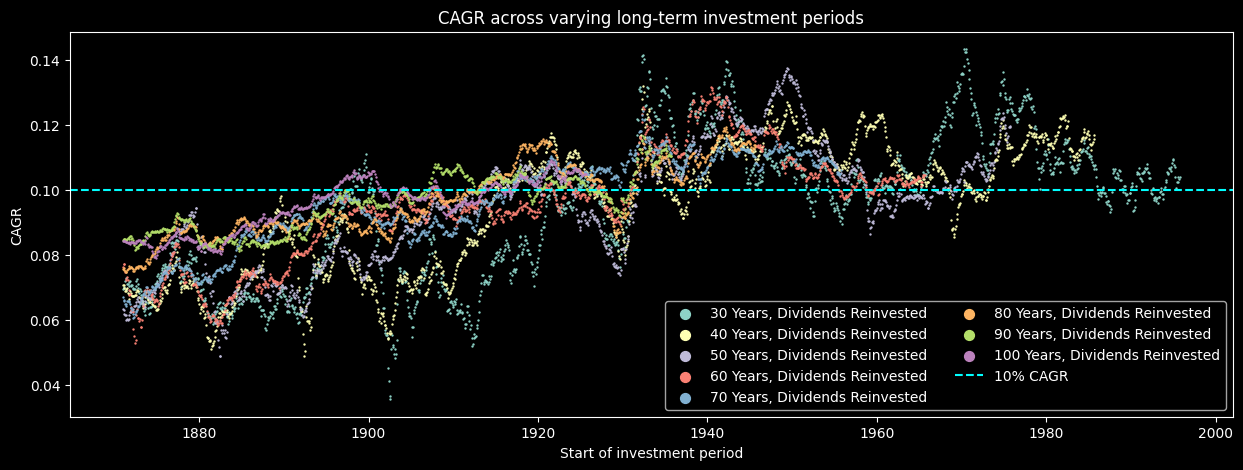

In [9]:
# Set (global) plot dimensions
pyplot.rcParams["figure.figsize"] = (15,5)
pyplot.style.use('dark_background')

for result in cagr_results:
    # Isolate longer periods for this plot
    if result['period'] < 30:
        continue

    dates = result['dates']
    cagr = result['cagr']
    period = result['period']
    pyplot.scatter(x=dates.to_list(), y=cagr.to_list(), s=0.5, label=f"{period} Years, Dividends Reinvested")

# Format the combined plot
pyplot.axhline(y=0.10, color='cyan', linestyle='dashed', label='10% CAGR') 
pyplot.legend(markerscale=10, ncol=2)
pyplot.xlabel('Start of investment period')
pyplot.ylabel('CAGR')
pyplot.title('CAGR across varying long-term investment periods')
pyplot.show()

#### Investment periods of 30 years or less

Particularly since the 1940s, the differences in 10, 20, and 30 year returns seem to straightforwardly reflect increasing time averages of the same underlying variations.  The 30 year period does again seem somewhat rosy in that it never seems to suffer a downward dip significantly below the 10% CAGR line seen in the 10 and 20 year periods.  It will be interesting in the next 5 or so years to see how longer investment periods perform when bought at the top of the dot com bubble. The 10 and 20 year periods suggest it could drag down long term CAGR periods when compared to the great depression era, but it's tough to tell.

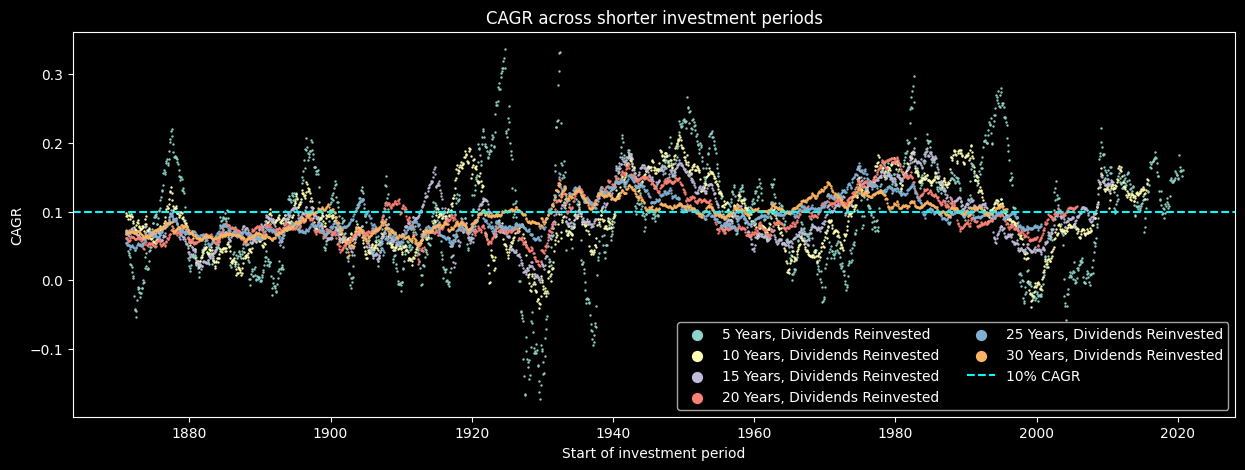

In [10]:
# Set (global) plot dimensions
pyplot.rcParams["figure.figsize"] = (15,5)
pyplot.style.use('dark_background')

for result in cagr_results:
    # Isolate shorter periods for this plot
    if result['period'] > 30:
        continue

    dates = result['dates']
    cagr = result['cagr']
    period = result['period']
    pyplot.scatter(x=dates.to_list(), y=cagr.to_list(), s=0.5, label=f"{period} Years, Dividends Reinvested")   

# Format the combined plot
pyplot.axhline(y=0.10, color='cyan', linestyle='dashed',label='10% CAGR') 
pyplot.legend(markerscale=10, ncol=2, loc='lower right')
pyplot.xlabel('Start of investment period')
pyplot.ylabel('CAGR')
pyplot.title('CAGR across shorter investment periods')
pyplot.show()

#### The impact of dividends

_Todo_

### Real CAGR (tests)

In [12]:
df.iloc[0]

Date                         1871-01-01 00:00:00
S&P                                         4.44
Dividend                                    0.26
Earnings                                     0.4
CPI                                    12.464061
Date Fraction                        1871.041667
Long Interest Rate                          5.32
Real Price                            115.921761
Real Dividend                           6.788211
Real Total Return Price               115.921761
Real Earnings                          10.443402
Real TR Scaled Earnings                10.443402
CAPE                                         NaN
TR CAPE                                      NaN
Excess CAPE Yield                            NaN
Monthly Bond Returns                    1.004177
Monthly Real Bond Returns                    1.0
10 Year Real Stock Return               0.130609
10 Year Real Bond Return                0.092504
10 Year Excess Return                   0.038106
Cumulative Dividend 

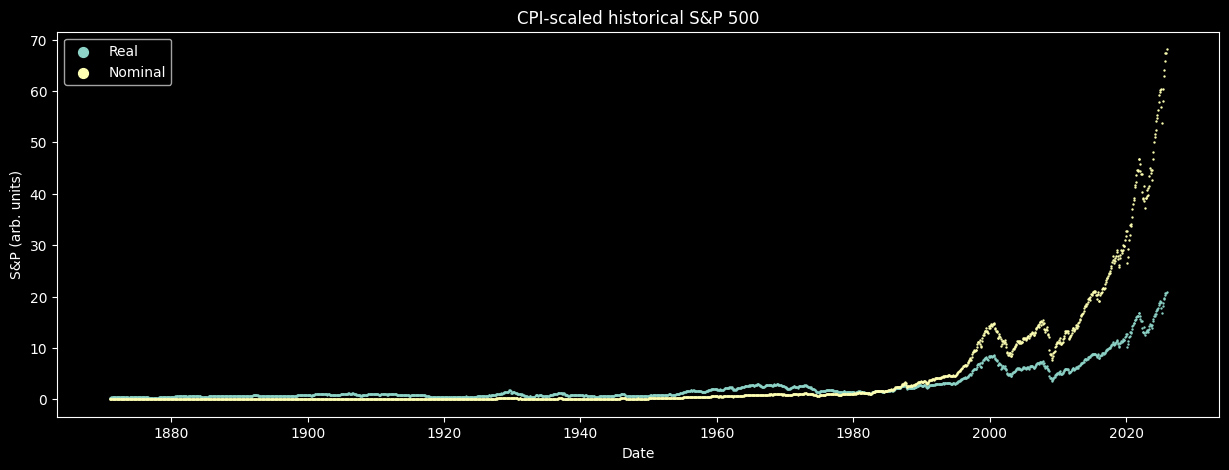

In [24]:
# Set (global) plot dimensions
pyplot.rcParams["figure.figsize"] = (15,5)
pyplot.style.use('dark_background')

dates = df['Date']
real_sp = df['S&P']/df['CPI']

nominal_sp = df['S&P'] / 100

pyplot.scatter(x=dates.to_list(), y=real_sp.to_list(), s=0.5, label="Real")   
pyplot.scatter(x=dates.to_list(), y=nominal_sp.to_list(), s=0.5, label="Nominal")   

# Format the combined plot
pyplot.xlabel('Date')
pyplot.ylabel('S&P (arb. units)')
pyplot.title('CPI-scaled historical S&P 500')
pyplot.legend(markerscale=10)
pyplot.show()